
# DL Final Exam

**Name:**

**Course Email:**  


## End of Assignment

Before submitting:
- Run all cells from top to bottom.  
- Check that all answer sections are filled.  
- Instruction video অনুযায়ী আমাদের দেয়া Colab ফাইলটি থেকে প্রথম একটি Save copy in drive করে নিবা। এরপর Google colab এর মধ্যে কোডগুলো করবে এবং সেই ফাইলটি ‘Anyone with the link’ & ‘View’ Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।

# Question 01: [ Marks 10 ]

## Explain the concept of backpropagation in detail. Describe how the error is propagated from the output layer to the hidden layers. Derive the mathematical expressions for weight updates using the chain rule, and explain how learning rate affects the training process.


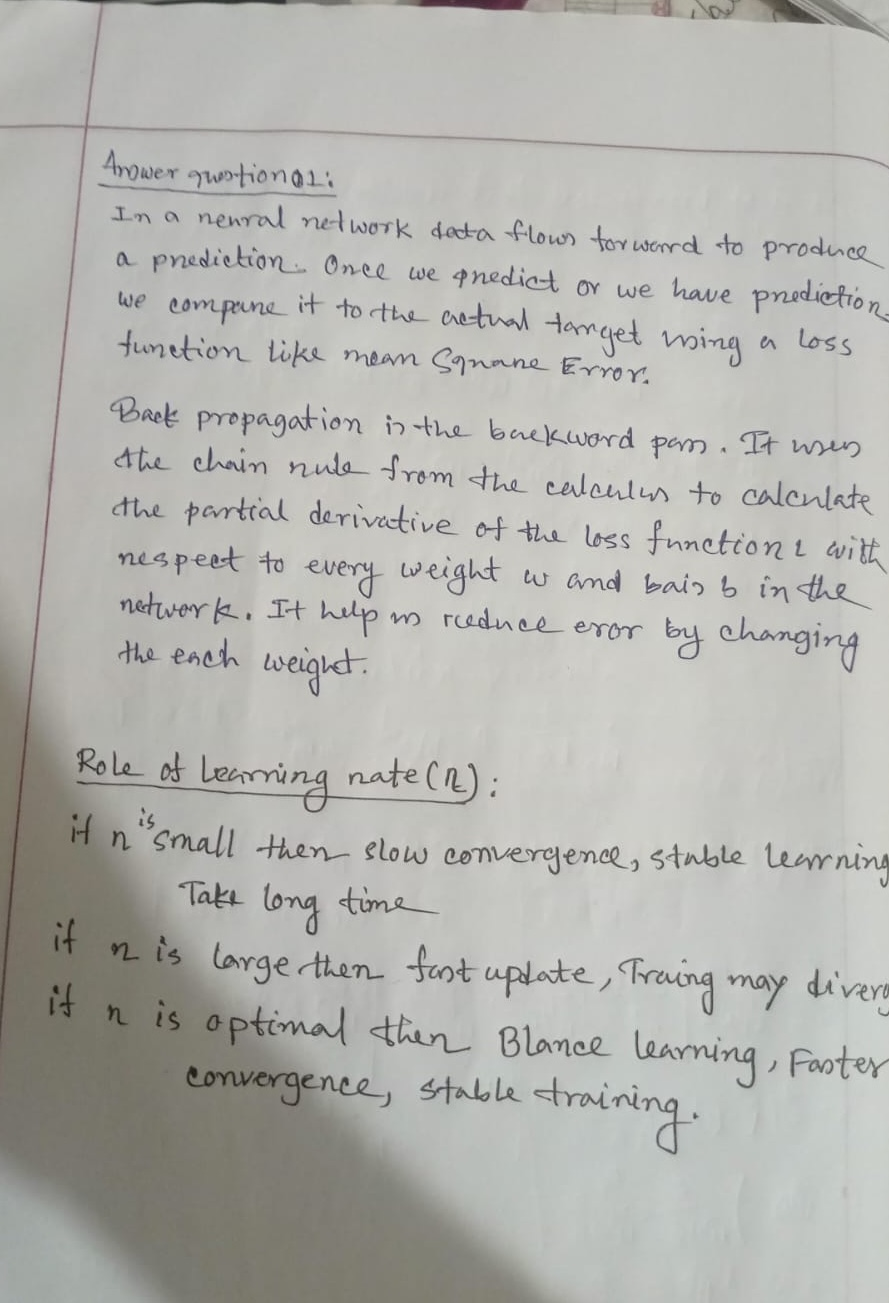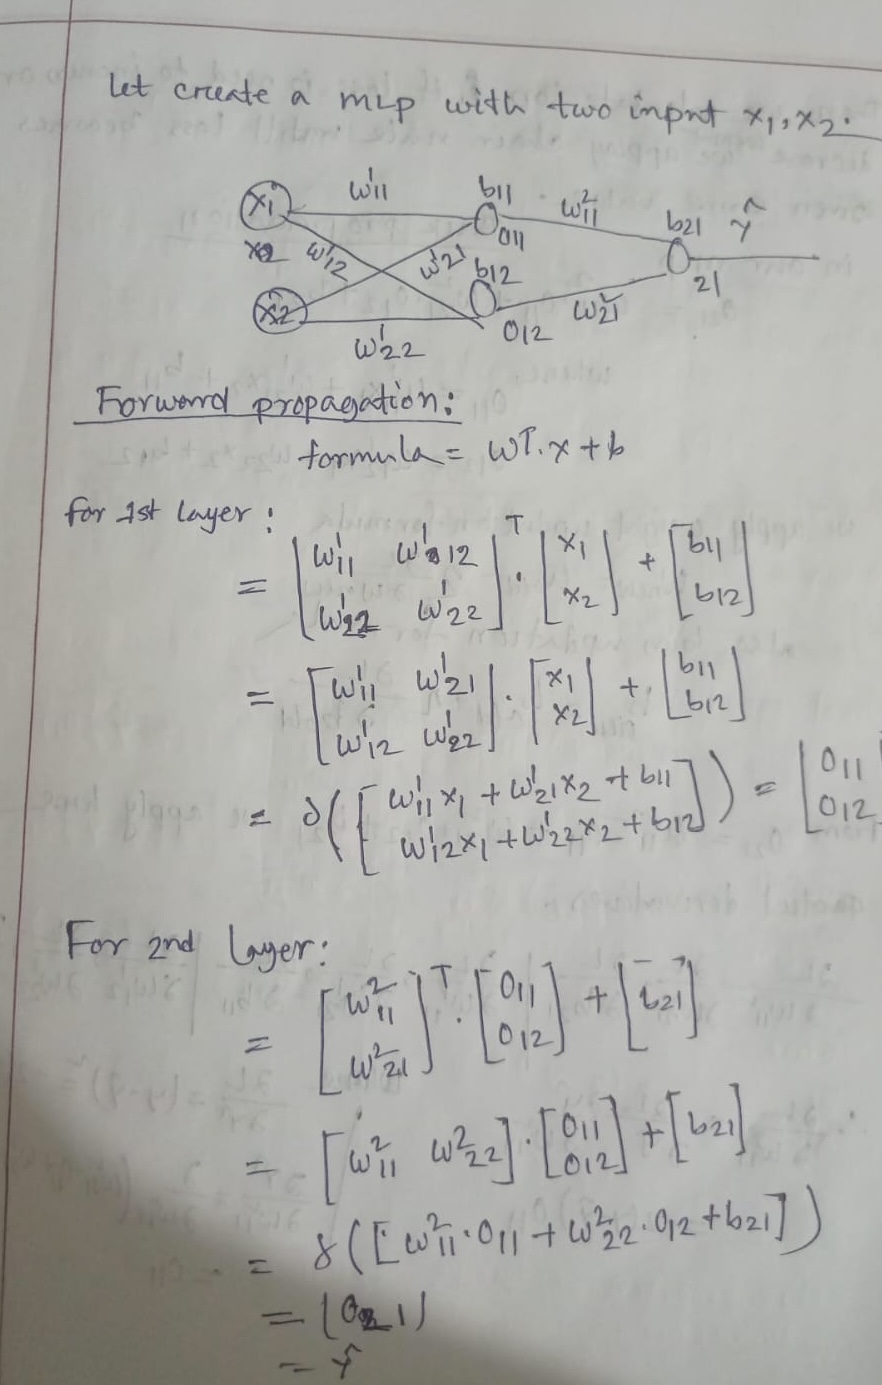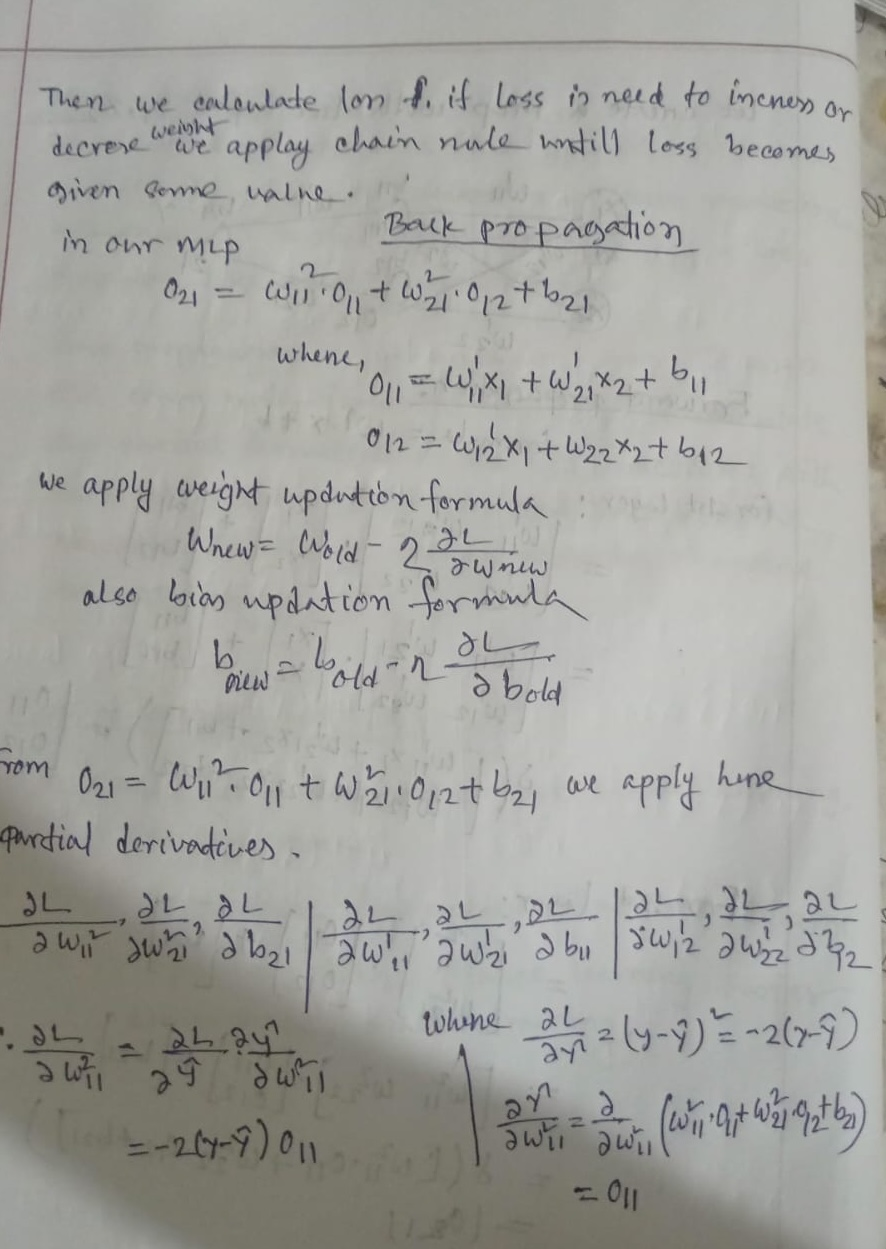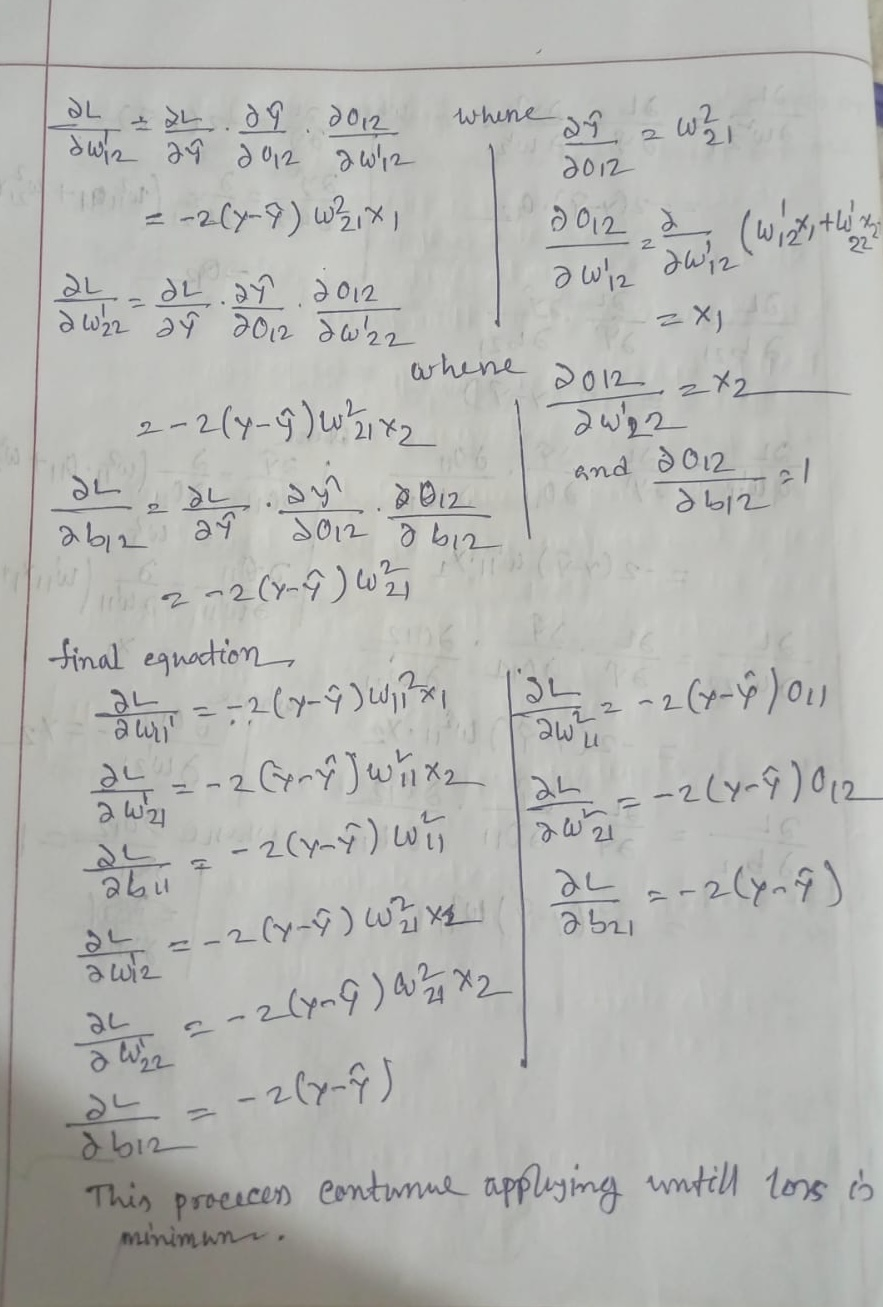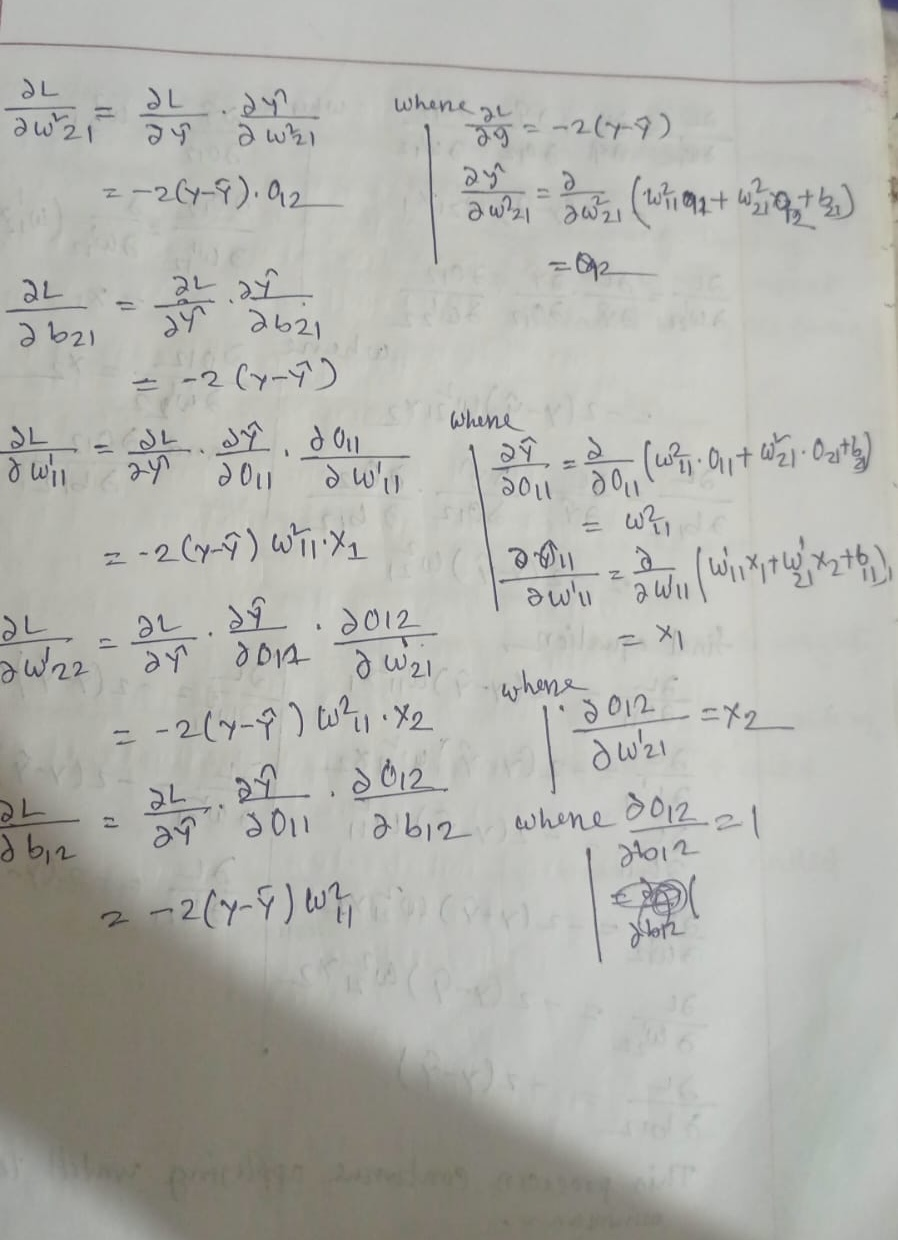# Write Answer 01:


# Question 02: [ Marks 10 ]

## Consider a neural network with one hidden layer using sigmoid activation. Derive the complete backpropagation equations for updating weights and biases. Show all steps clearly, including forward pass, loss calculation, and backward pass.

## Write Answer 02:

---

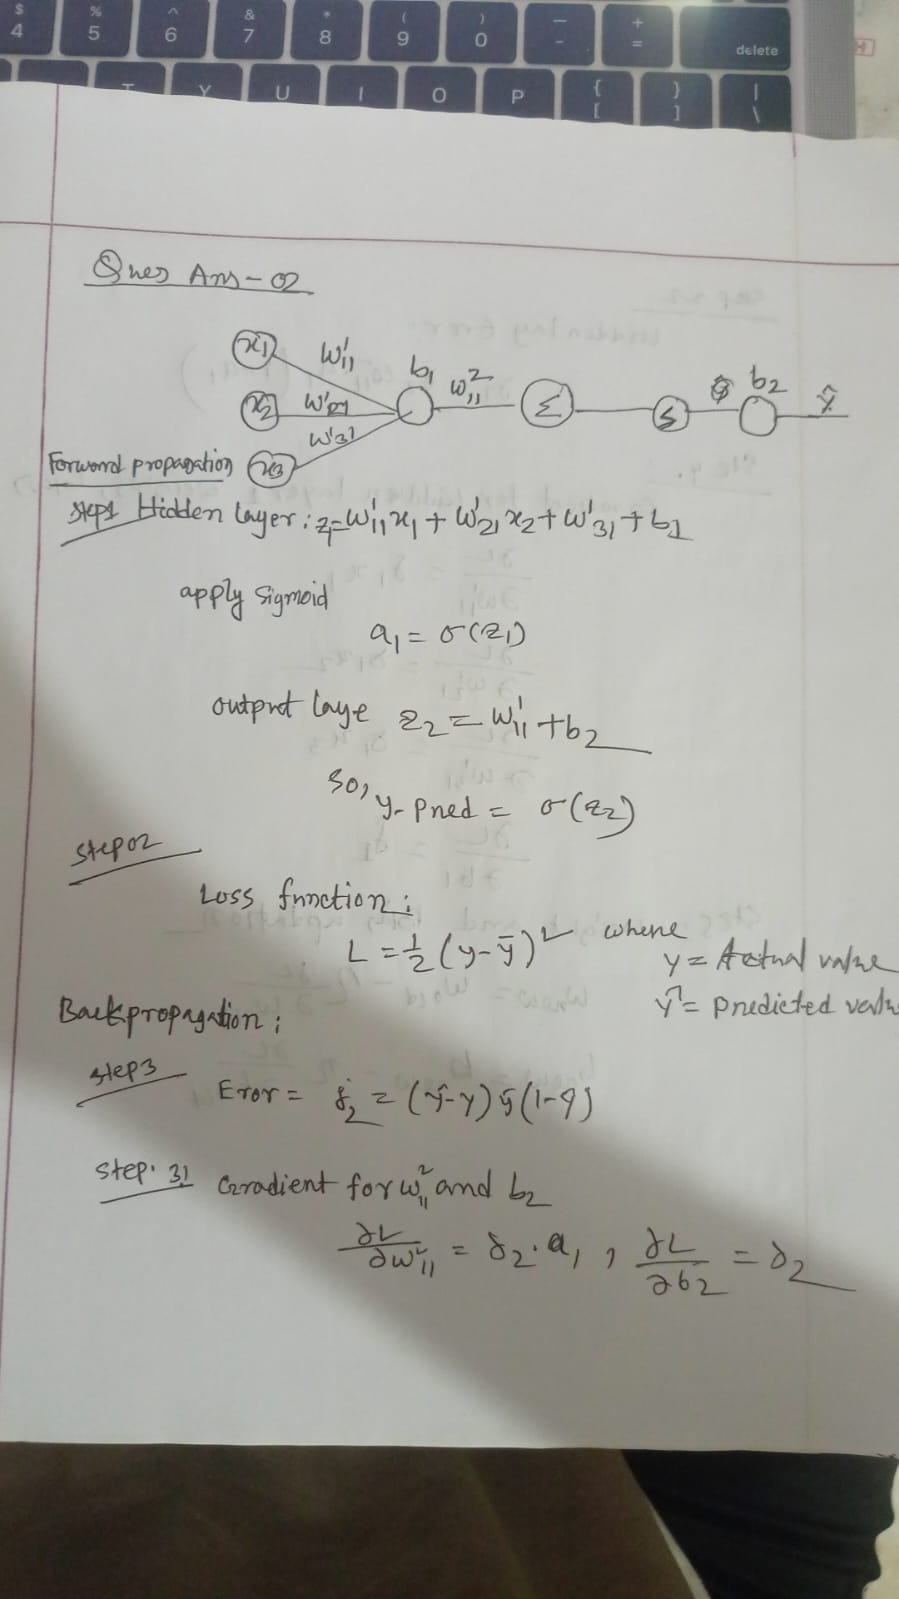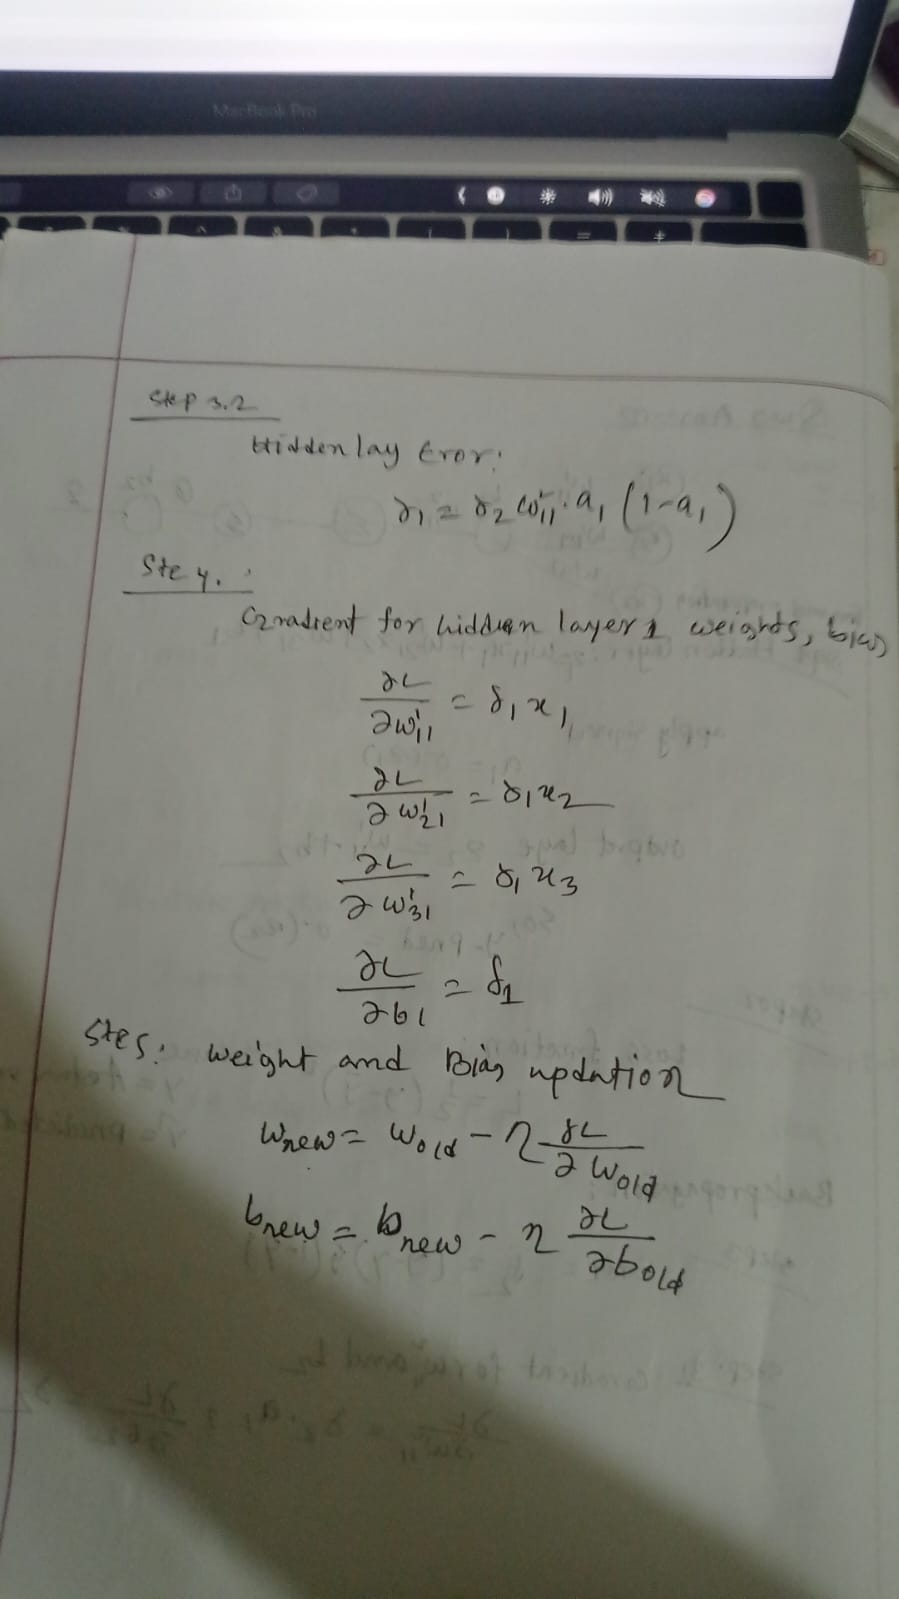


# Question 03: [Marks 5]

## Discuss the vanishing gradient problems in deep neural networks. Explain why they occur during backpropagation, how activation functions contribute to this issue, and suggest at least three techniques to overcome these problems.


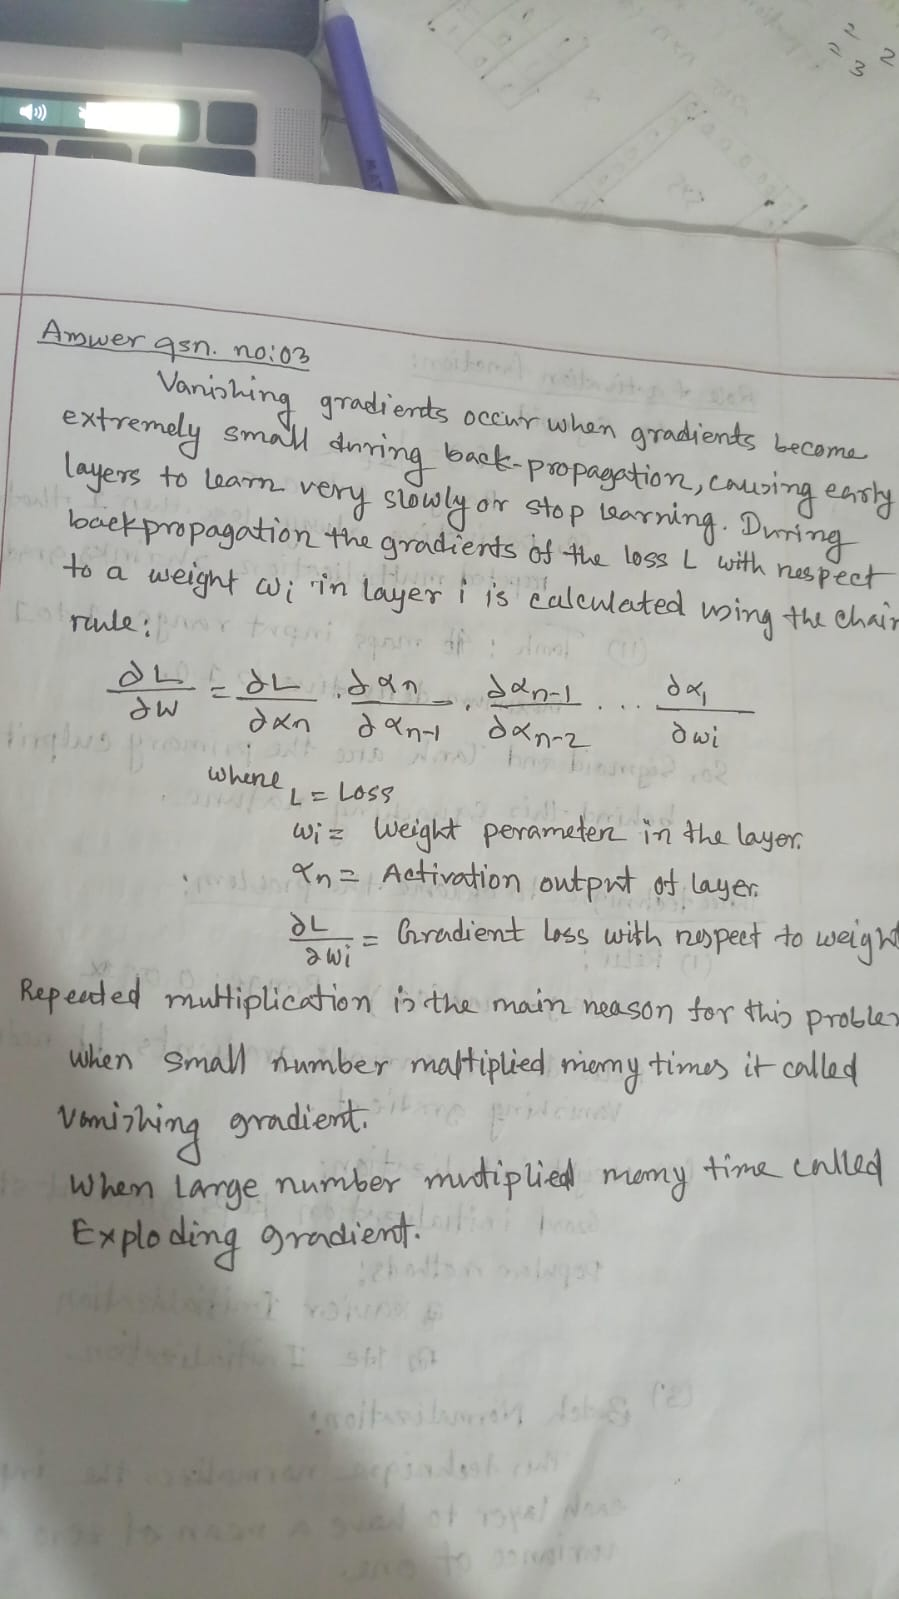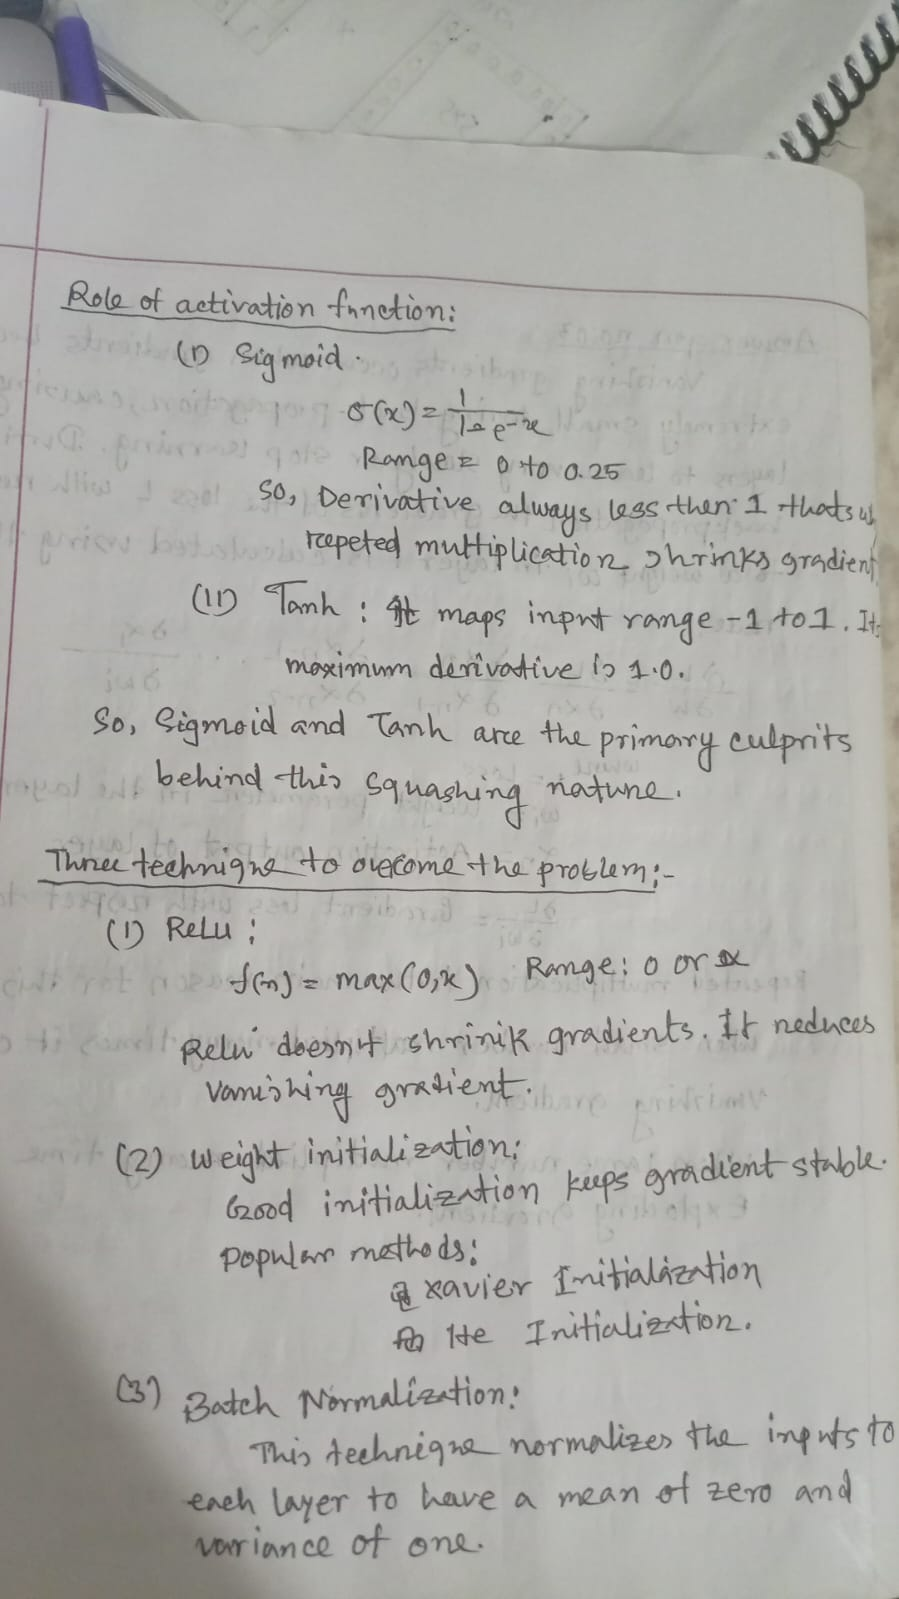## Write Answer 03:

# Question 04: [ Marks 5 ]

## Describe the architecture of an Artificial Neural Network (ANN) in detail. Explain the role of each component (neurons, weights, bias, activation functions). Also discuss how increasing the number of hidden layers and neurons affects model performance and overfitting.


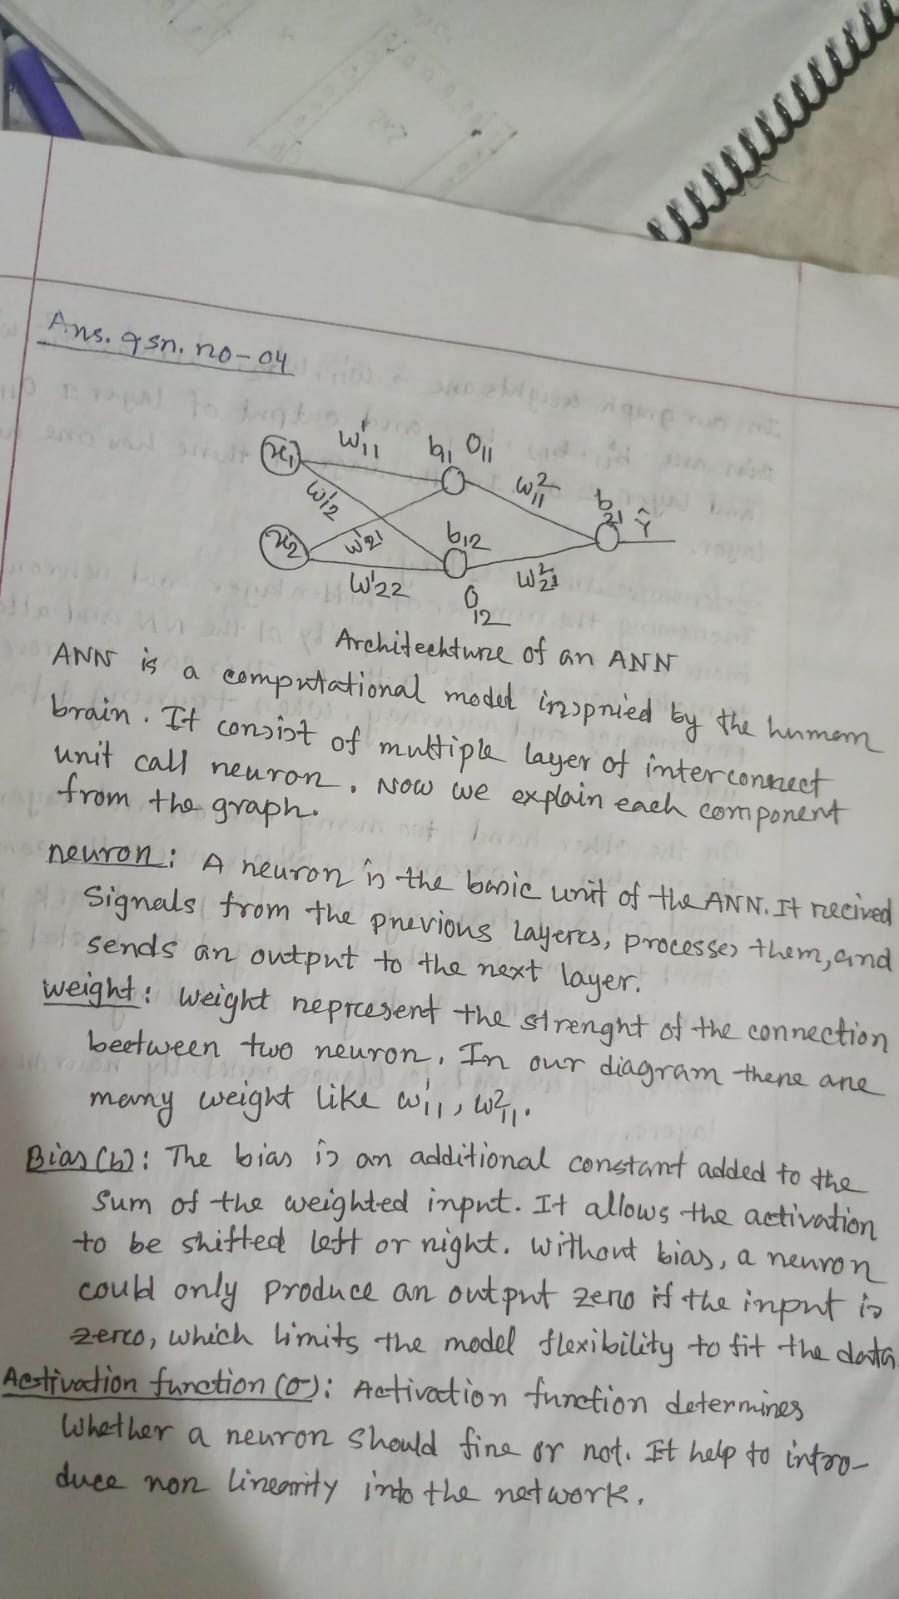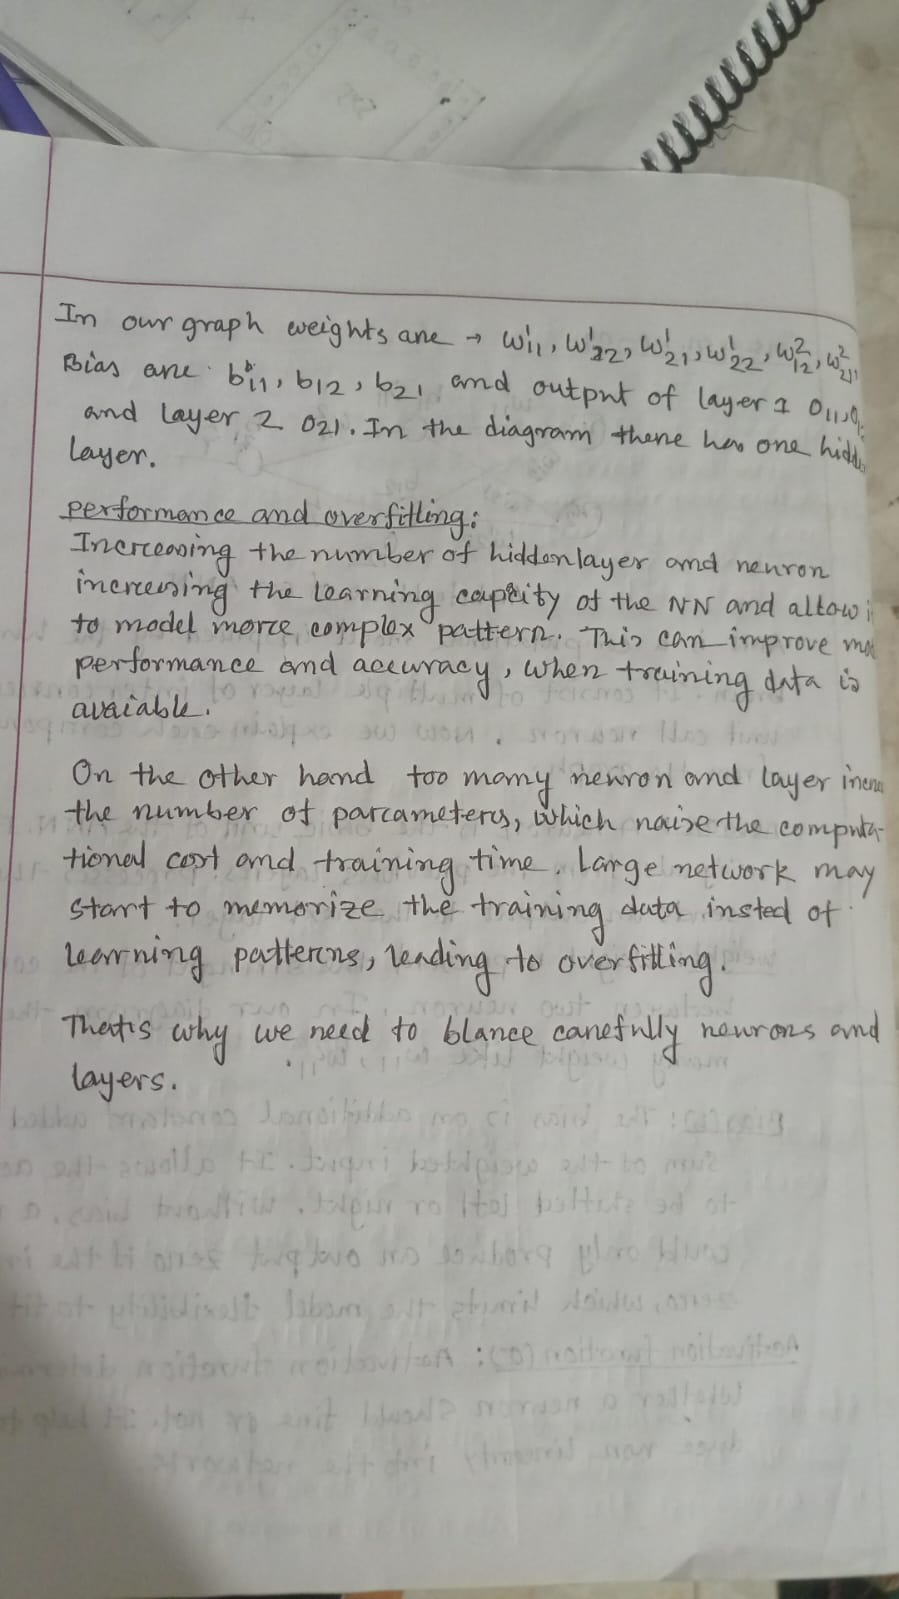

# Question 05: [ Marks 10 ]

## Compare Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN) in detail. Discuss their architectures, working principles, advantages, limitations, and typical use cases such as image processing, tabular data, and pattern recognition.

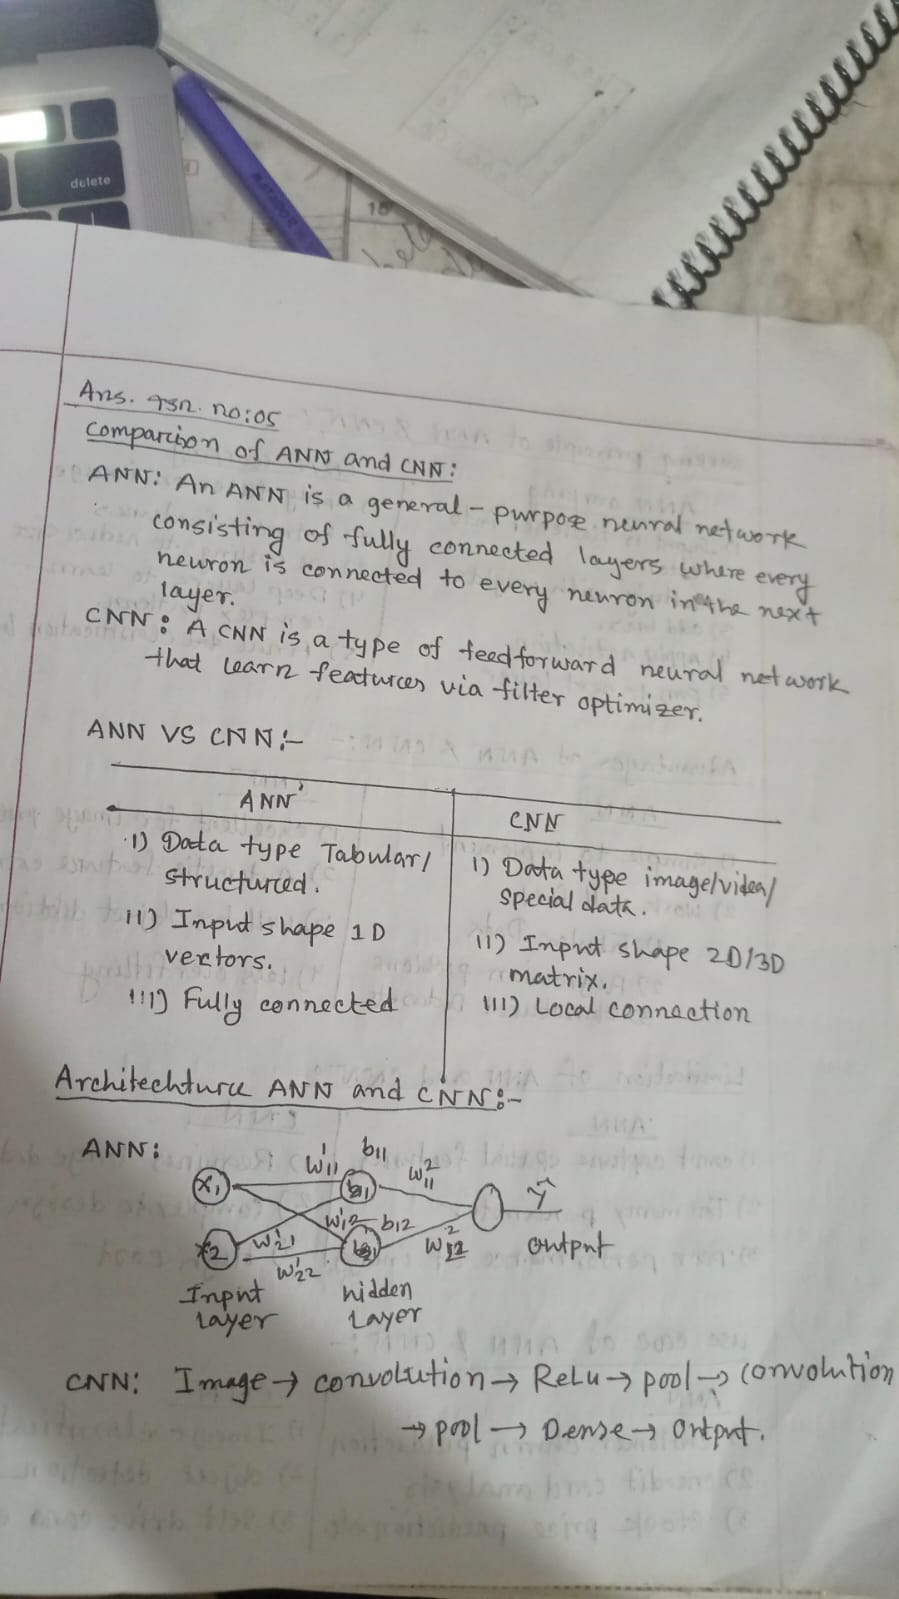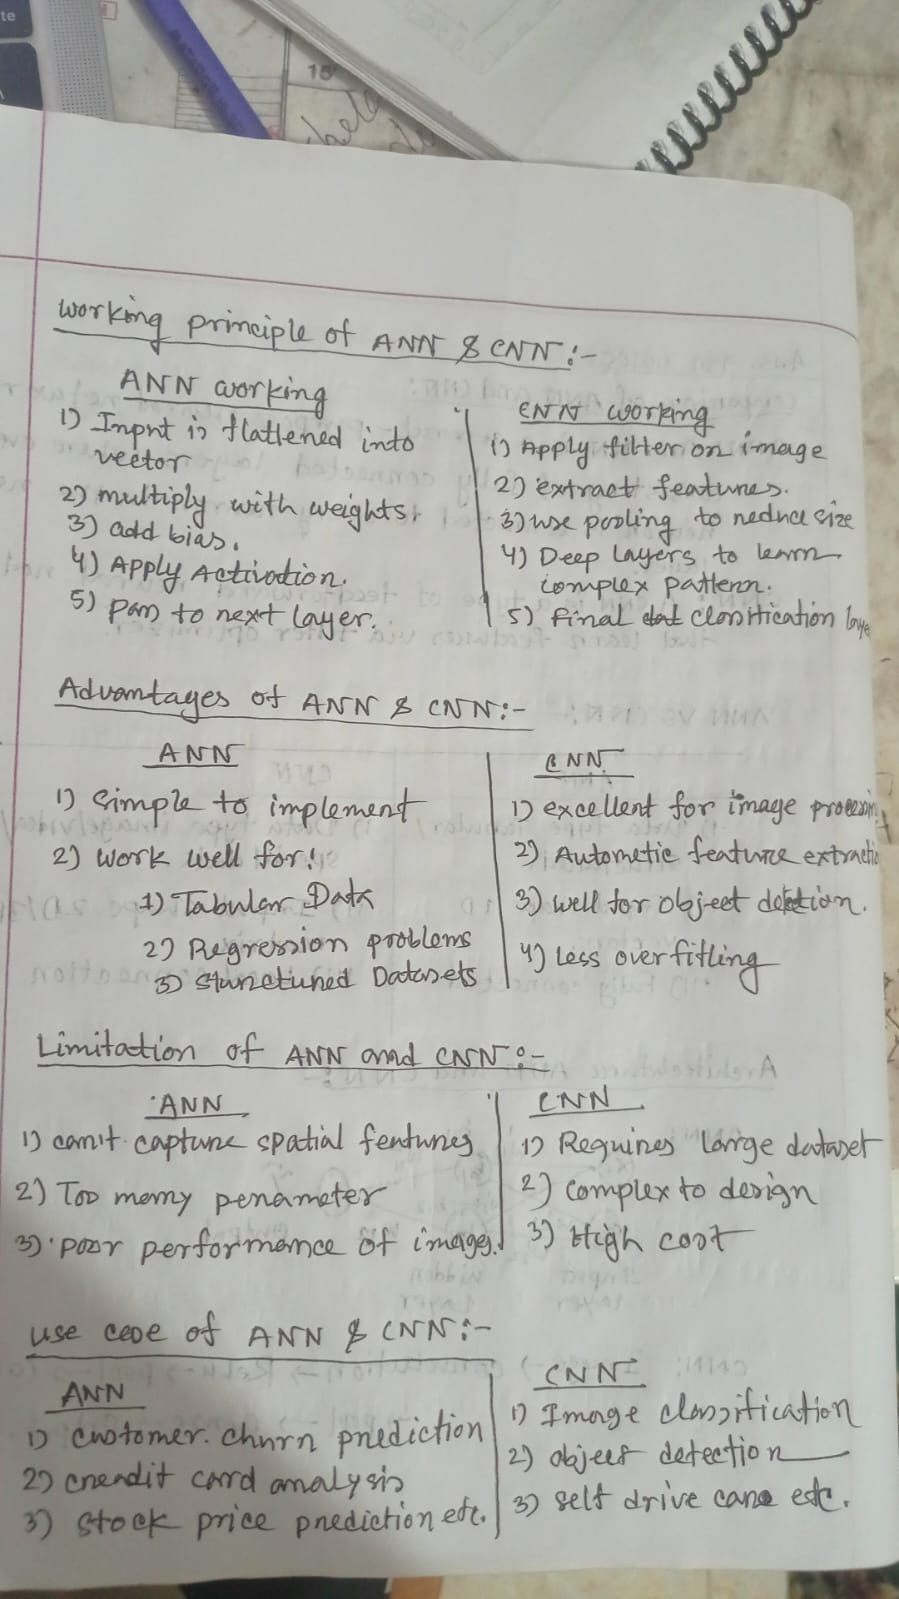## Write Answer 05:

# Question 06: [ Marks 10 ]

## Explain different activation functions used in neural networks, including Sigmoid, Tanh, and ReLU. Provide their mathematical formulas, advantages, disadvantages, and suitable use cases. Also discuss why ReLU is widely used in deep learning.

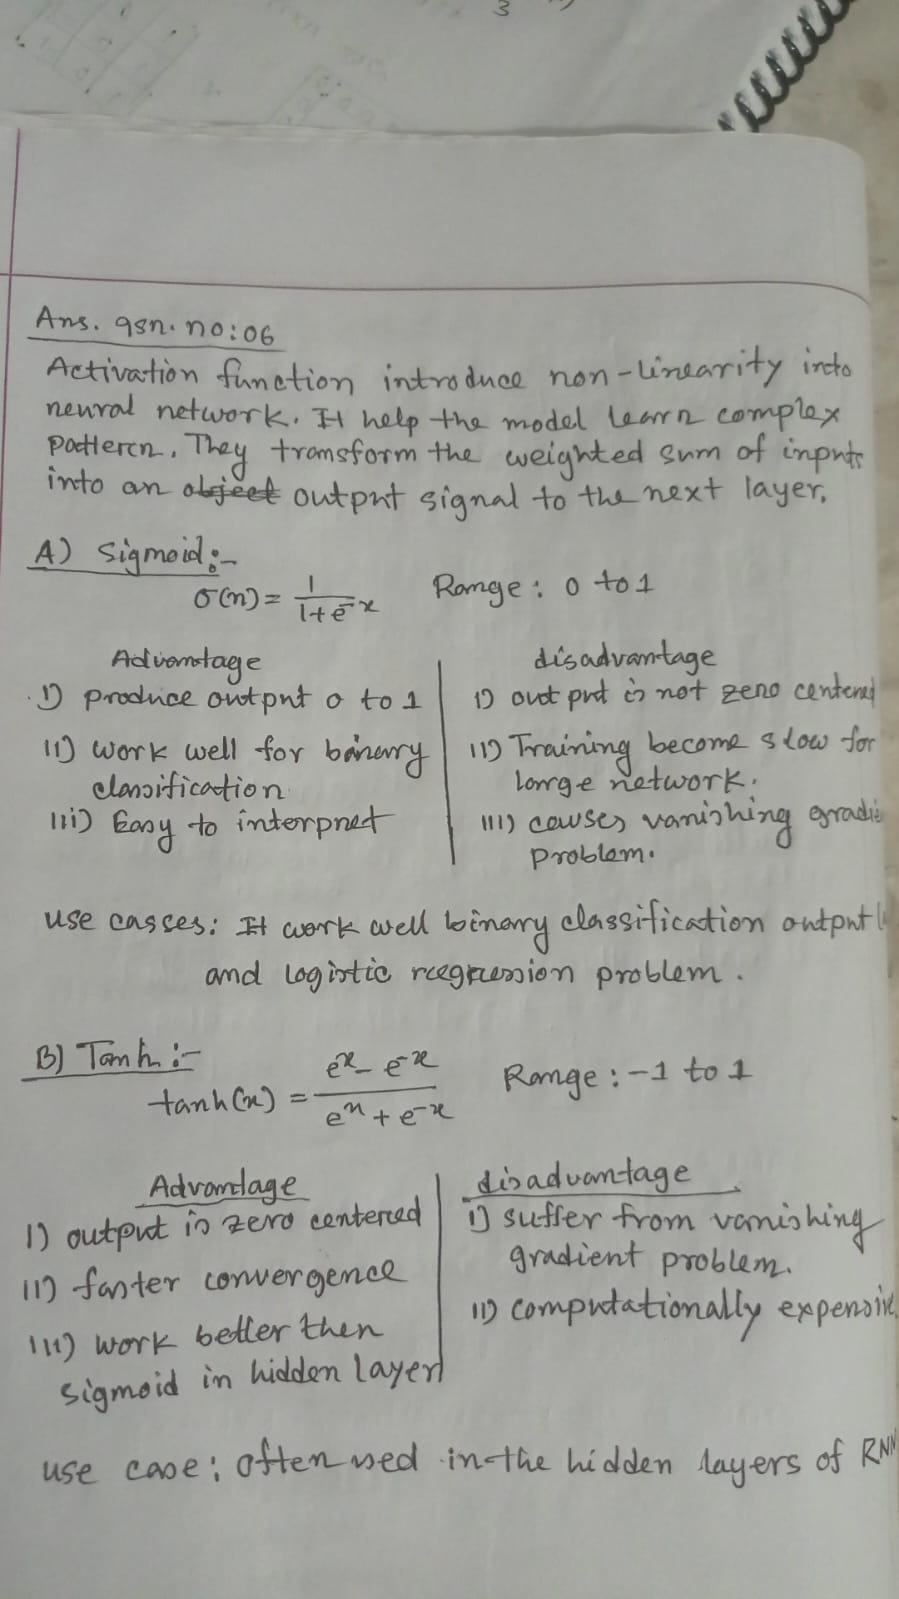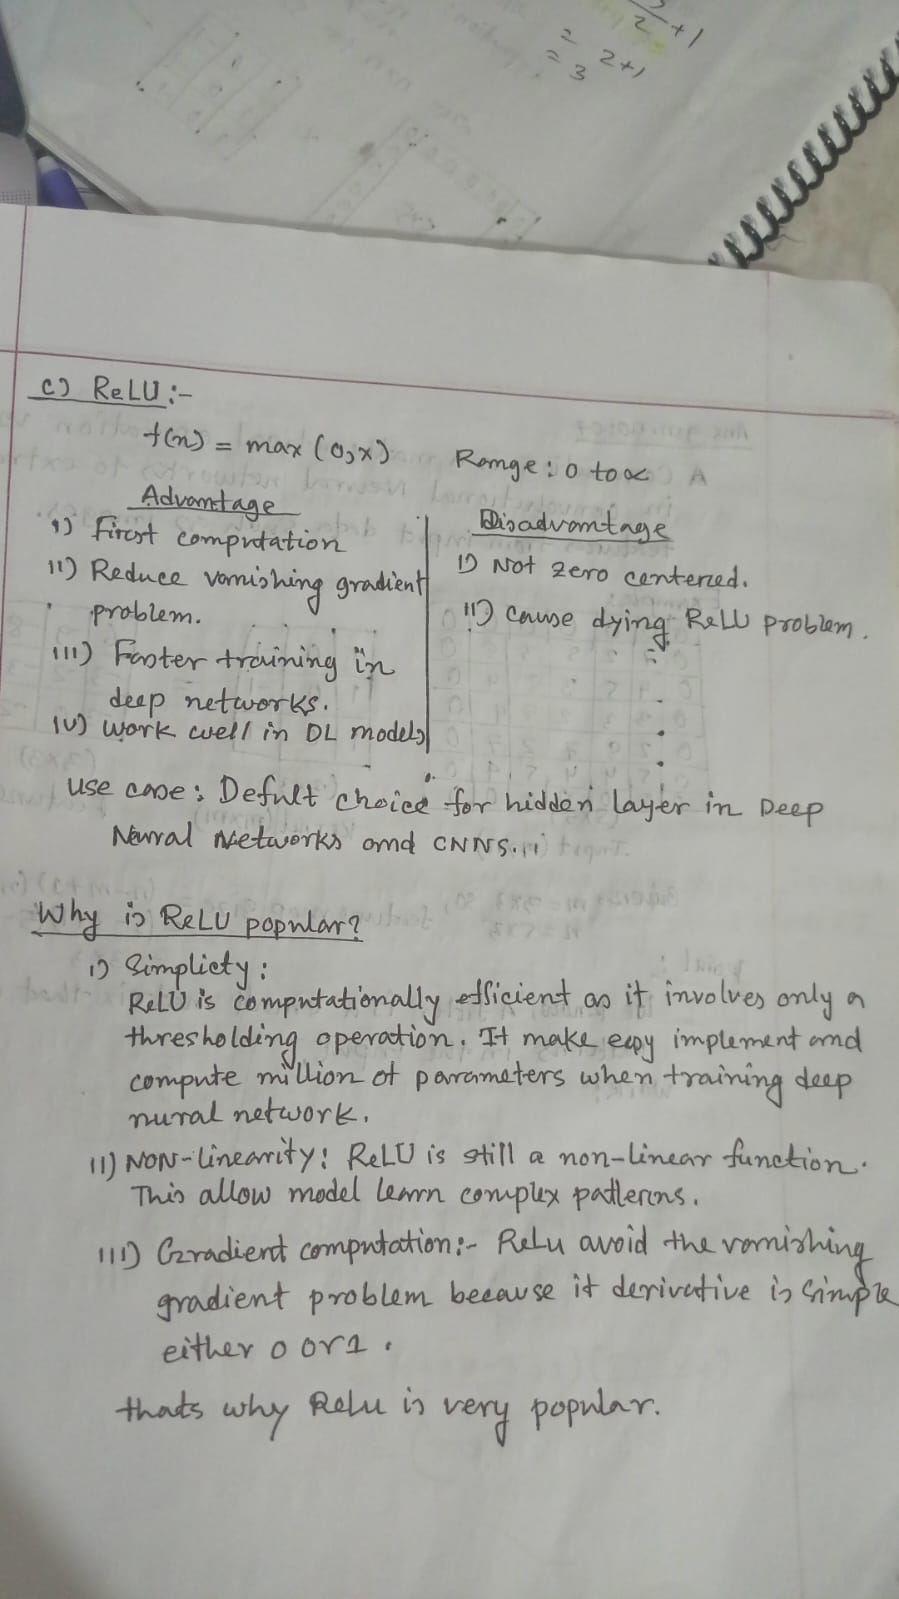## Write Answer 06:

# Question 07: [ Marks 10 ]

## Describe the convolution operation in CNNs in detail. Explain how filters (kernels) work, how feature maps are generated, and how parameters like stride and padding affect the output. Provide a step-by-step example using a small input matrix.
Note :  You've to attach an image here.



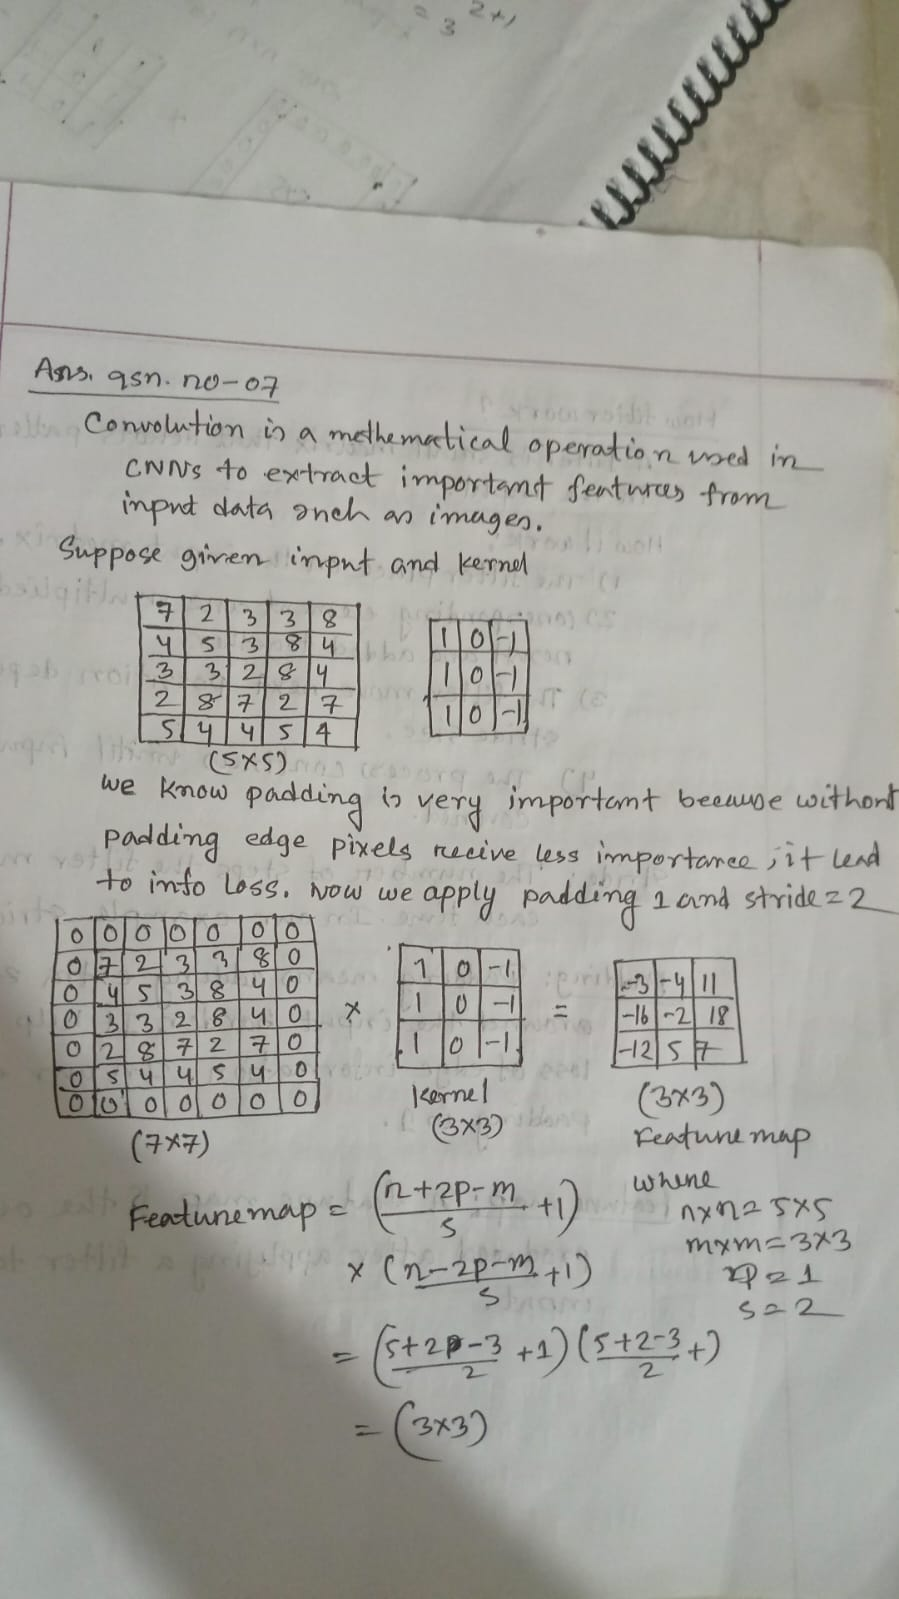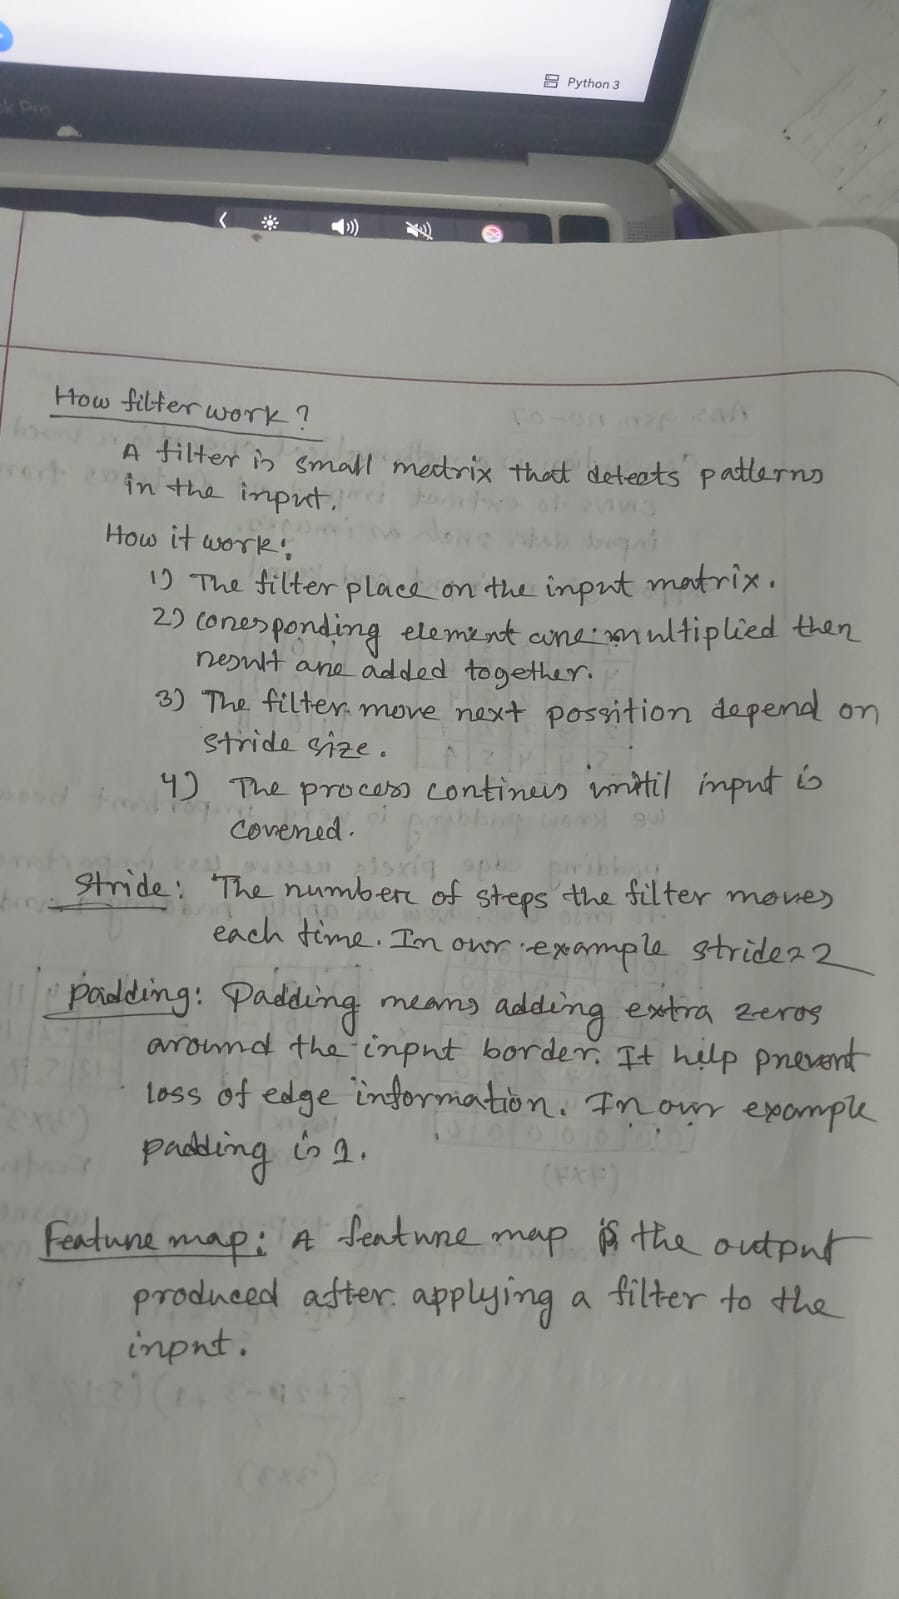## Write Answer 07:



# Question 08: [ Marks 10 ]

## Explain the concept of pooling in CNNs. Compare MaxPooling and AveragePooling in terms of operation, advantages, and impact on feature extraction. Discuss how pooling helps in reducing overfitting and computational complexity.

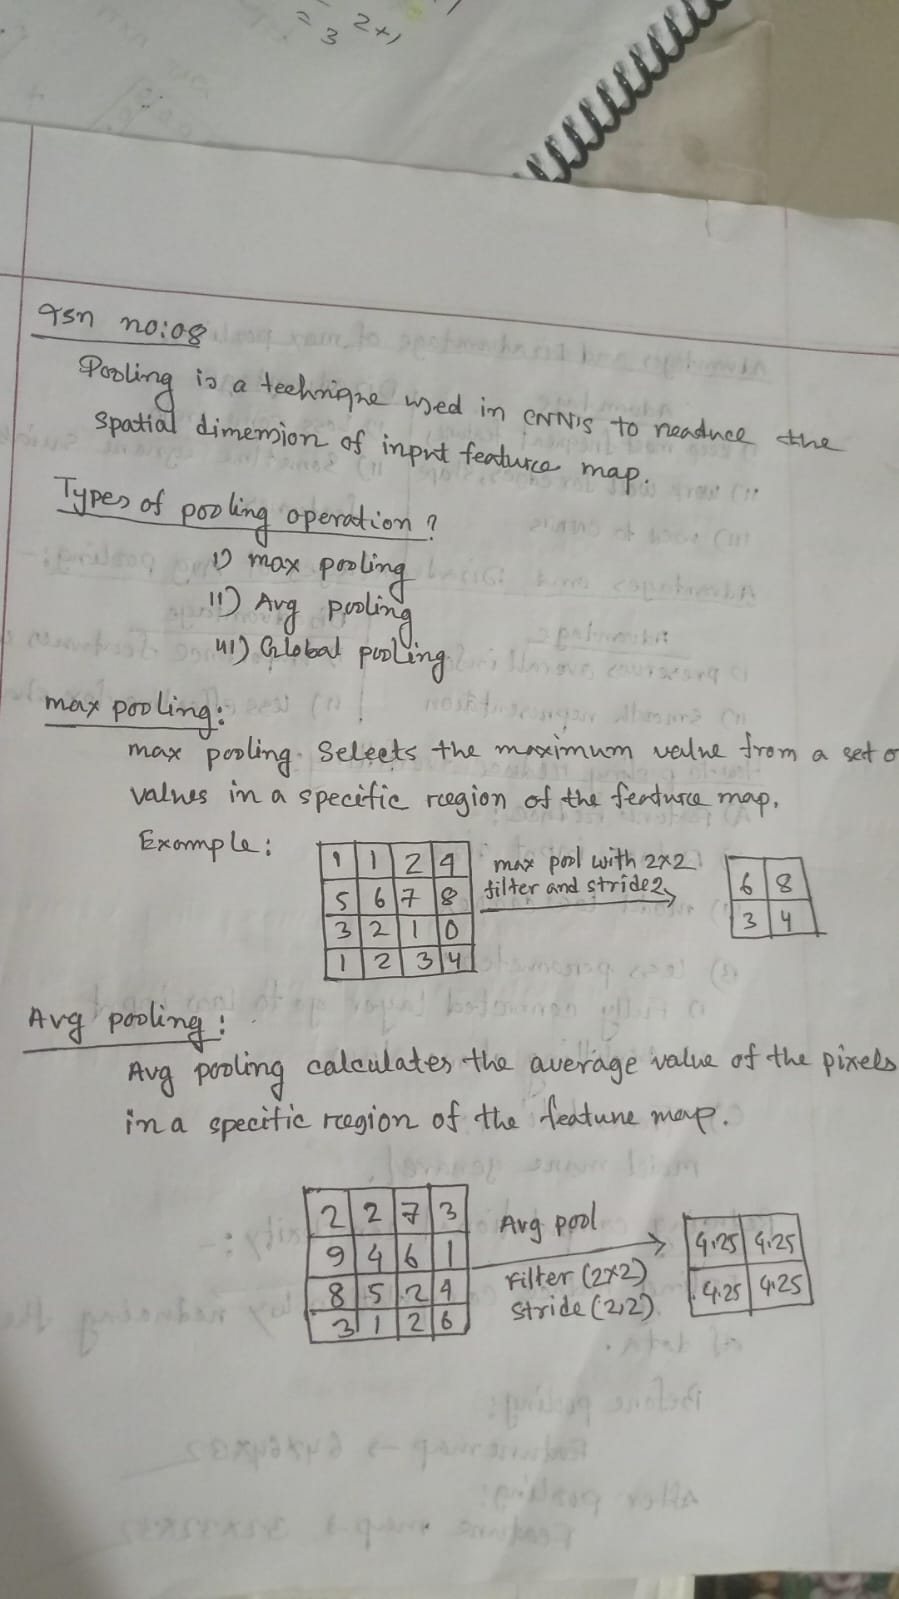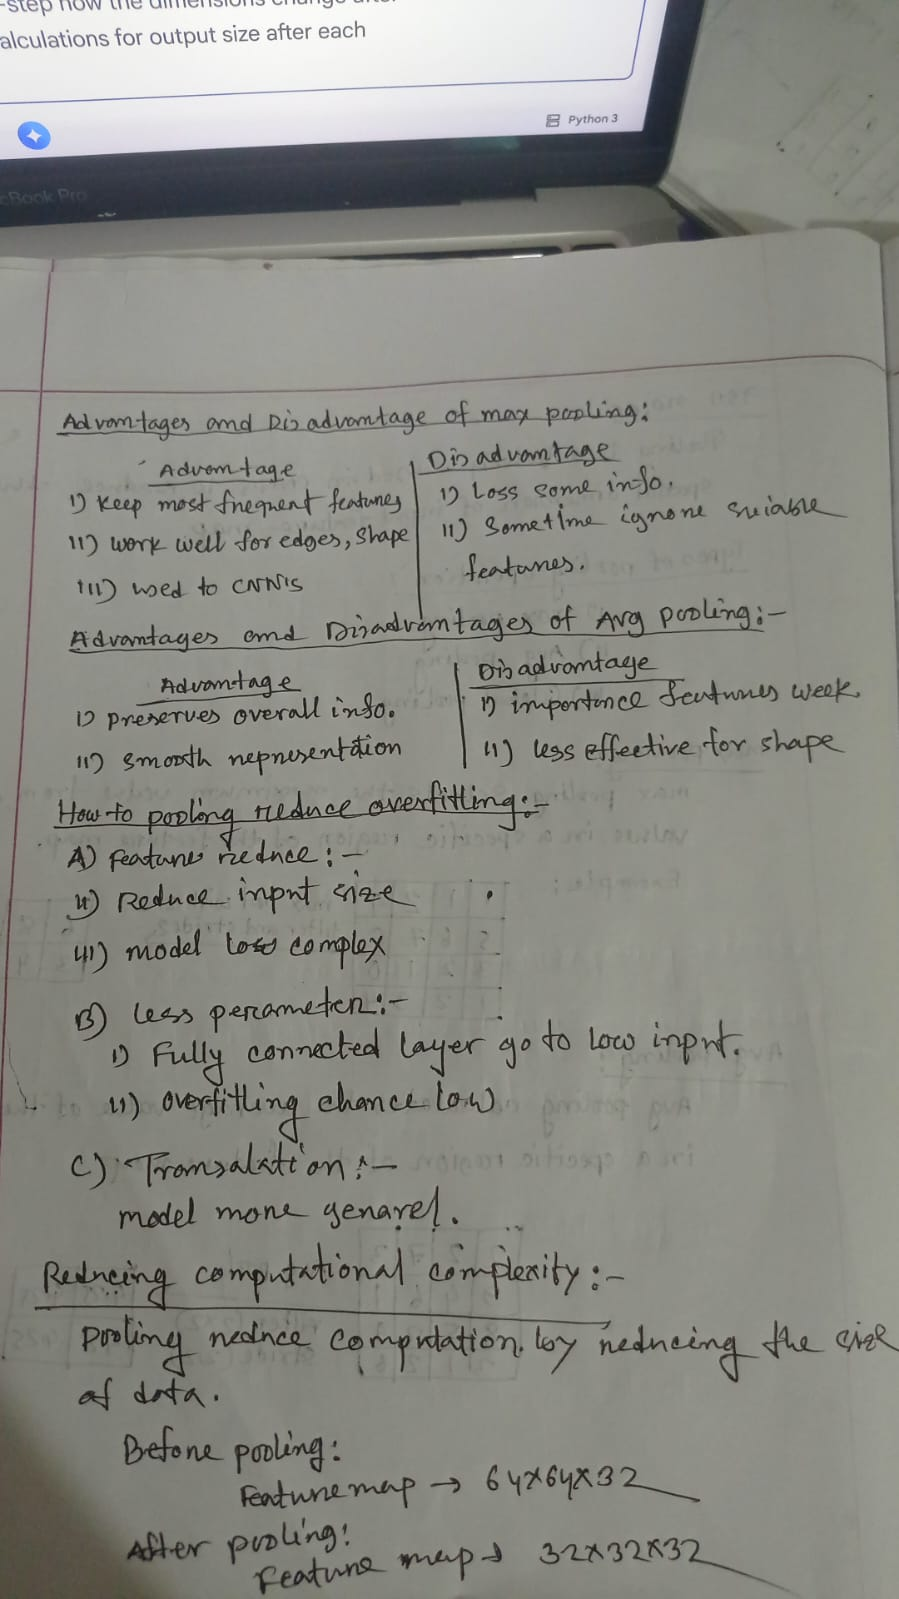Write Answer 08:

# Question 09: [ Marks 10 ]

## Given an input image of size 128×128×3, explain step-by-step how the dimensions change after multiple convolution and pooling layers. Clearly show calculations for output size after each layer using appropriate formulas.

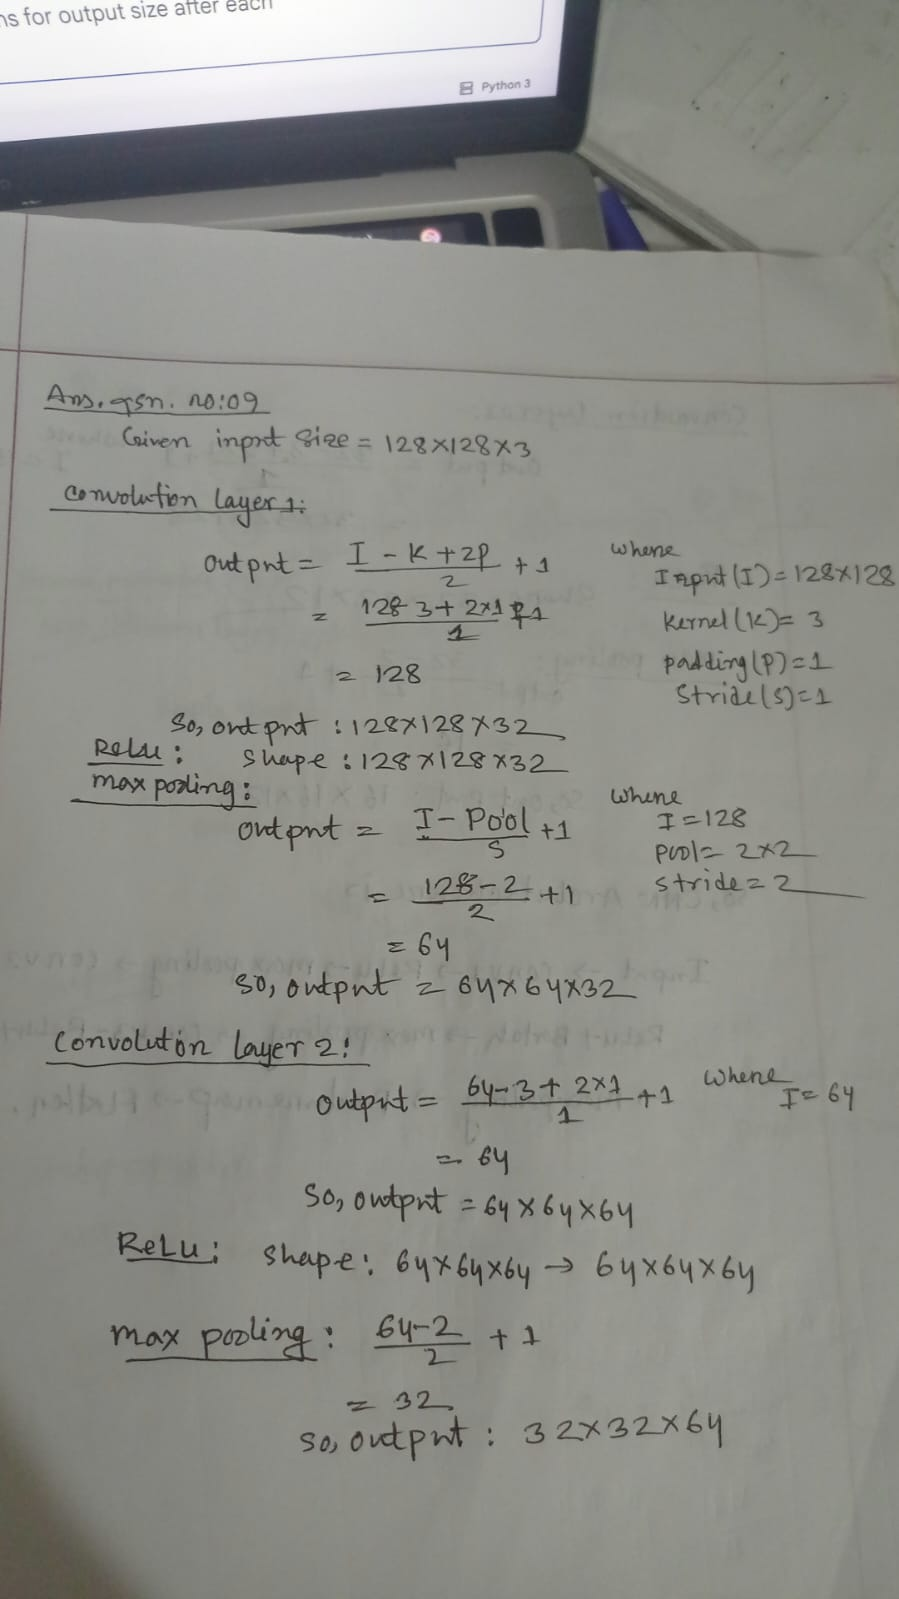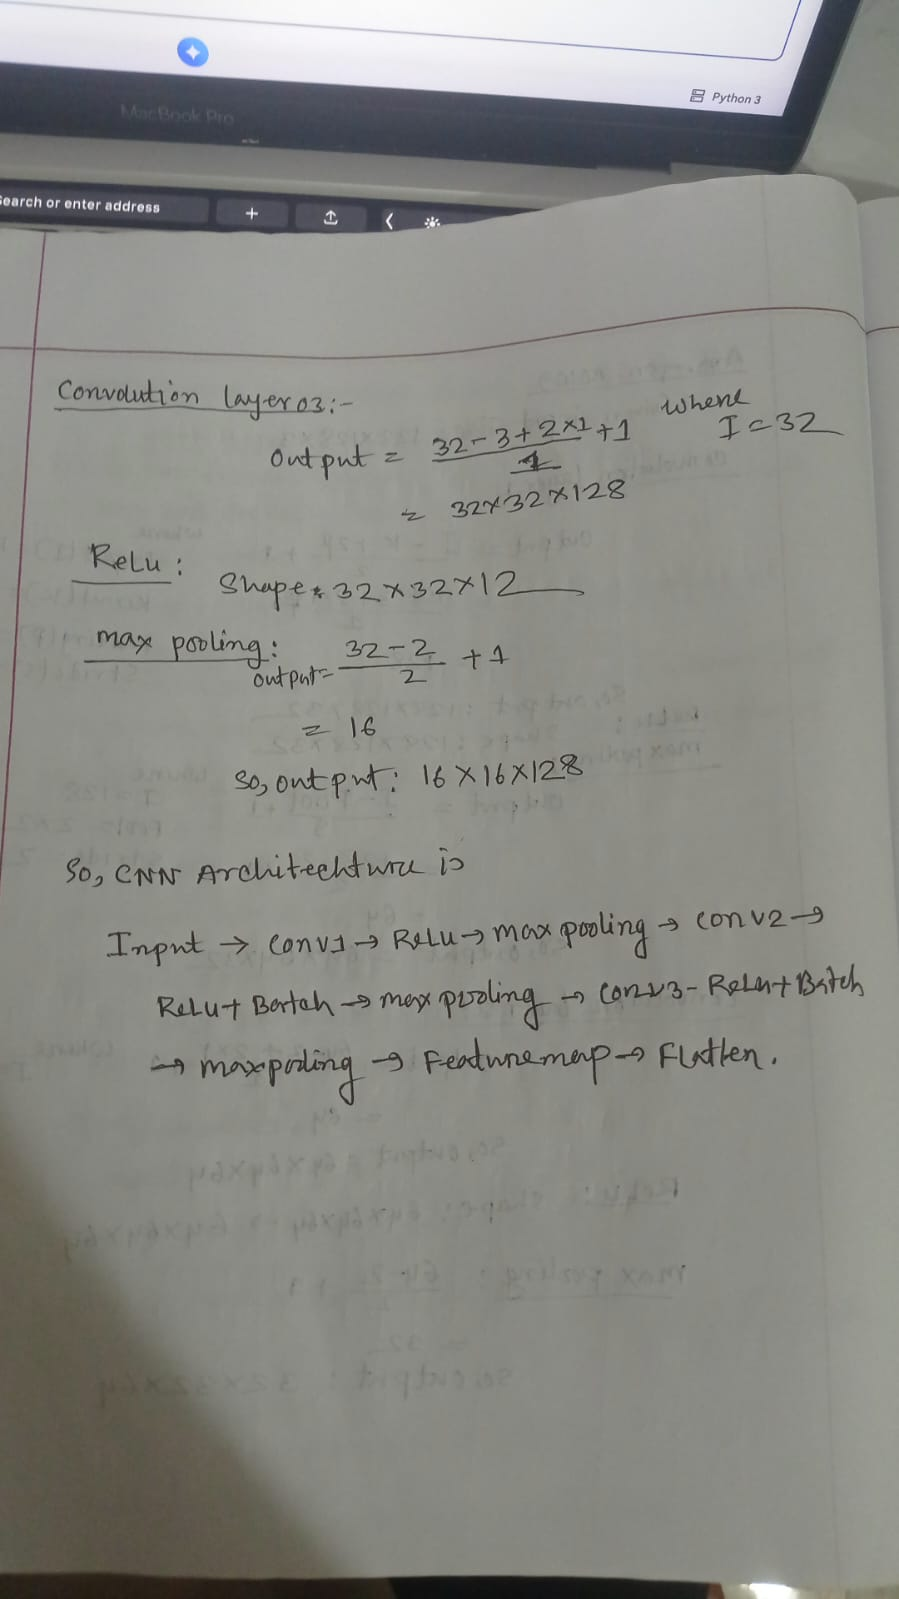# Write Answer 09:

# Question 10: [ Marks 20 ]

## Design and implement a deep Convolutional Neural Network (CNN) for a multi-class image classification problem using PyTorch. The network should consist of four convolutional blocks, where each block includes two convolution layers followed by activation and normalization, and a pooling layer at the end. The number of filters should increase progressively across blocks. After the convolutional part, flatten the feature maps and connect them to fully connected layers with dropout for regularization, and produce final outputs corresponding to K classes. Also explain the role of each part of the network in detail.

# Write Answer 10:

In [ ]:
print('Requried laibraries')
print('-'*40)
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset,DataLoader,Subset
from PIL import Image
import kagglehub
print('DONE!')



Requried laibraries
----------------------------------------
DONE!


In [ ]:
print('Load Dataset')
print('-'*40)

path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')
print('dataset path',path)

print('dataset load done!')

Load Dataset
----------------------------------------
Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
dataset path /kaggle/input/chest-xray-pneumonia
dataset load done!


In [ ]:
print('Load Dataset')
print('-'*40)

path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')
print('dataset path',path)

print('dataset load done!')

cheak CUDA
----------------------------------------
 Using Device cuda


In [ ]:
print('Train test initailization')
print('-'*40)

TRAIN_PATH = os.path.join(path, "chest_xray", "train")
TEST_PATH = os.path.join(path, "chest_xray", "test")
VAL_PATH = os.path.join(path, "chest_xray", "val")
print('DONE!')

Train test initailization
----------------------------------------
DONE!


In [ ]:
print('appling transfrom')
print('-'*40)

transform = transforms.Compose(
    [
        transforms.Resize( (128,128) ),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ]
)

print('appling transfrom done!')

appling transfrom
----------------------------------------
appling transfrom done!


In [ ]:
from genericpath import isfile

class MultiClassClassfication(Dataset):
  def __init__(self, root_dir,transform=None) :

    super().__init__()
    self.samples = []
    self.transform = transform

    self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir,d))])
    self.class_to_idx= {cls_name : idx  for idx,cls_name in enumerate(self.classes)}

    for class_name in self.classes:
      class_path = os.path.join(root_dir,class_name)
      for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path,img_name)

        if os.path.isfile(img_path):
          label = self.class_to_idx[class_name]
          self.samples.append( (img_path,label) )


  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx) :

    img_path, label = self.samples[idx]
    image = Image.open(img_path).convert("RGB")

    if self.transform:
      image = self.transform(image)
    return image, label

In [ ]:
print('Load Data')
print('-'*40)

train_dataset_full = MultiClassClassfication(TRAIN_PATH, transform)
test_dataset_full = MultiClassClassfication(VAL_PATH, transform)
num_classes = len(train_dataset_full.classes)

print("Number of classes:", num_classes)
print("Full train size:", len(train_dataset_full))
print("Full test size:", len(test_dataset_full))



Load Data
----------------------------------------
Number of classes: 2
Full train size: 5216
Full test size: 16


In [ ]:
print('Use sub_set')
print('-'*40)

train_dataset = Subset(train_dataset_full, list(range (0, len(train_dataset_full))))
test_dataset = Subset(test_dataset_full, list(range(0, len(test_dataset_full))))

print('DONE!')

Use sub_set
----------------------------------------
DONE!


In [ ]:
print('apply dataloader')
print('-'*40)

pin = True if device.type == 'cuda' else False
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=pin)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=pin)

print('apply dataloader done!')

apply dataloader
----------------------------------------
apply dataloader done!


In [ ]:
print('model define')
print('-'*40)

class MyCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print('DONE!')

model define
----------------------------------------
DONE!


In [ ]:
print('parameter initialization')
print('-'*40)
model = MyCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 10

print('DONE!')

parameter initialization
----------------------------------------
DONE!


In [ ]:
print('training loop')
print('-'*40)

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

training loop
----------------------------------------
Epoch 1/10, Loss: 0.1950
Epoch 2/10, Loss: 0.1038
Epoch 3/10, Loss: 0.0707
Epoch 4/10, Loss: 0.0612
Epoch 5/10, Loss: 0.0465
Epoch 6/10, Loss: 0.0423
Epoch 7/10, Loss: 0.0321
Epoch 8/10, Loss: 0.0262
Epoch 9/10, Loss: 0.0203
Epoch 10/10, Loss: 0.0173


In [ ]:
def evaluate(loader):
    model.eval()
    total, correct = 0, 0
    with torch.no_grad():
        for batch_features, batch_labels in loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            outputs = model(batch_features)
            _, predicted = torch.max(outputs, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()
    return correct / total

In [ ]:
test_acc = evaluate(test_loader)
print("Test Accuracy:", test_acc)
train_acc = evaluate(train_loader)
print("Train Accuracy:", train_acc)

Test Accuracy: 0.9375
Train Accuracy: 0.9994248466257669
